In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def prepare_df_clinical_variables(data_df):
    """ Setup dataset with the clinical covariates. """
    list_covariates = ['birth_days_to', 'dss_survival_days', 'dss_censorship', 'sex', 'ajcc_pathologic_tumor_stage']
    column_dict = {"birth_days_to": "age", "dss_survival_days": "survival_time", "dss_censorship": "event", "ajcc_pathologic_tumor_stage": "stage"}
    
    if 'histological_grade' in data_df.columns.tolist():
        list_covariates.append('histological_grade')
        column_dict['histological_grade'] = 'grade'

    data_df= data_df[list_covariates]
    data_df = data_df.rename(columns=column_dict)

    # Map the column 
    # Event is the opposite of censorship
    data_df['event'] = data_df['event'].apply(lambda x: 'Unsure' if x == 1 else "Death")

    # age is -1 * birth days to
    data_df['age'] = data_df['age'] * -1 # In months.

    return data_df
    
def visualize_df(clinical_df, name):
    """ Visualizes the clinical variables. """
    print("Visualizing " + name)
    # Plotting the distributions of clinical variables
    for column in clinical_df.columns.tolist():
        plt.figure(figsize=(8, 4))
        if clinical_df[column].nunique() <= 20:  # Categorical or ordinal variable
            ax = sns.countplot(x=column, hue=column, data=clinical_df, palette='coolwarm', legend=False)
            plt.title(f"Distribution of {column} for {name}")
            plt.xlabel(column)
            if len(ax.containers) > 5:
                plt.xticks(rotation=45, ha='right')
            plt.ylabel("Count")
            for container in ax.containers:
                ax.bar_label(container)
        else:  # Continuous variable
            sns.histplot(clinical_df[column], kde=True, color='blue')
            plt.title(f"Distribution of {column}")
            plt.xlabel(column)
            plt.ylabel("Density")
        plt.show()



Visualizing tcga_kirc


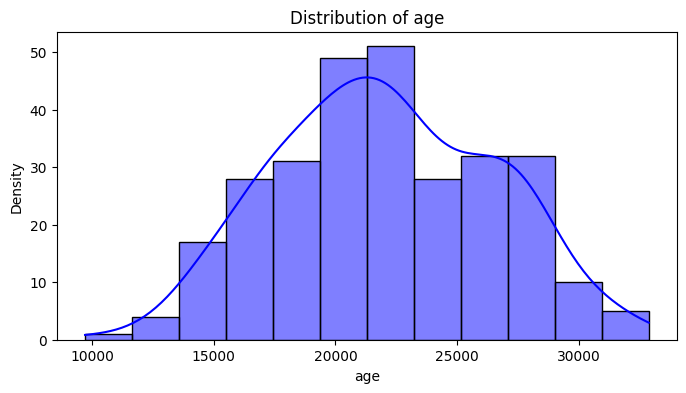

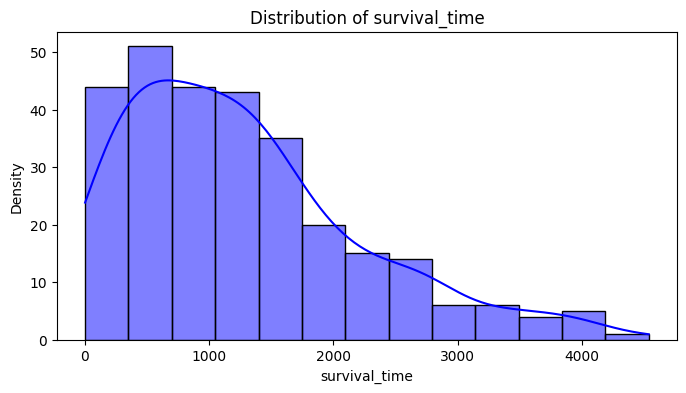

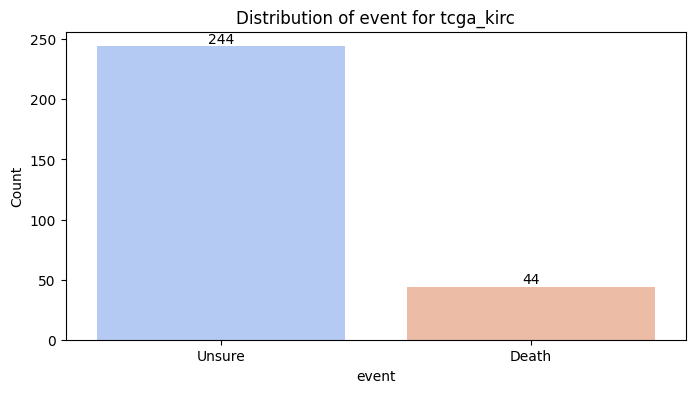

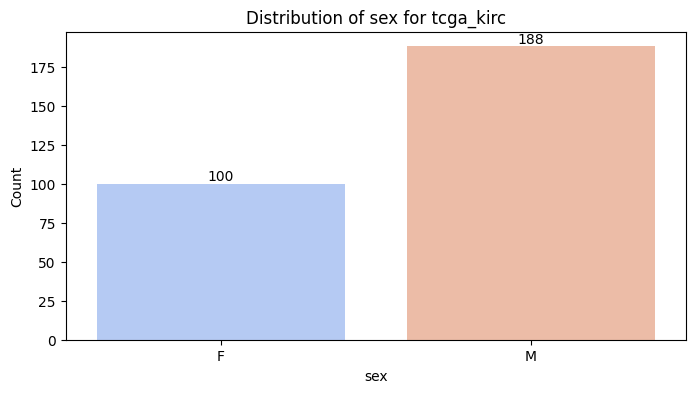

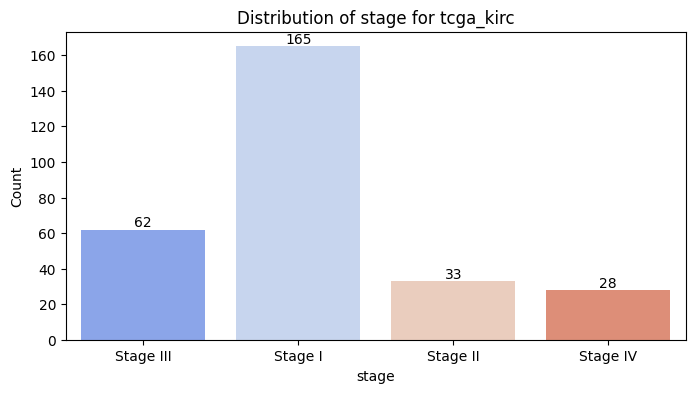

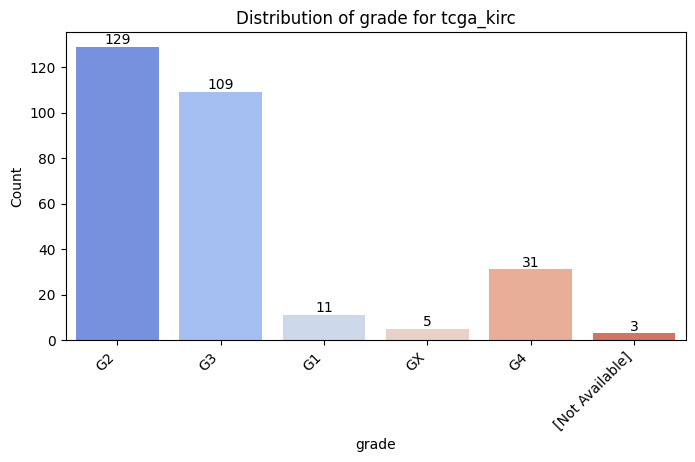

In [4]:
data_src = 'tcga_kirc' # OR 'tcga_brca', 'tcga_luad', 'tcga_kirc'
clinical_data_source = f'data_files/{data_src}/splits/0/train.csv'

data_df = pd.read_csv(clinical_data_source)
data_df_prepped = prepare_df_clinical_variables(data_df)

visualize_df(data_df_prepped, data_src)


Visualizing tcga_kirc


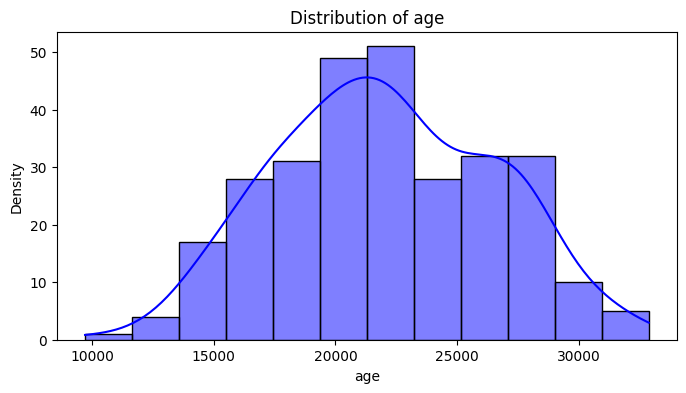

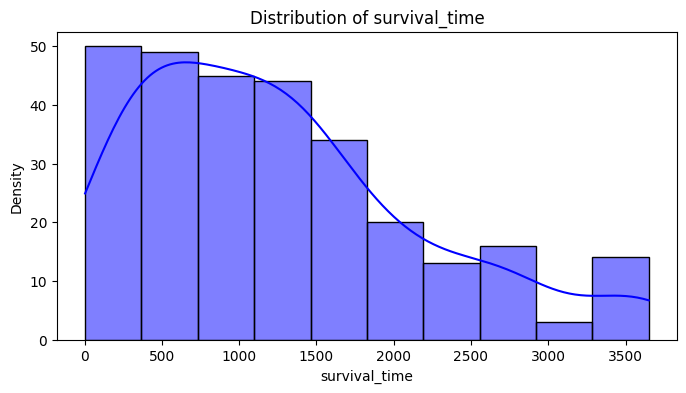

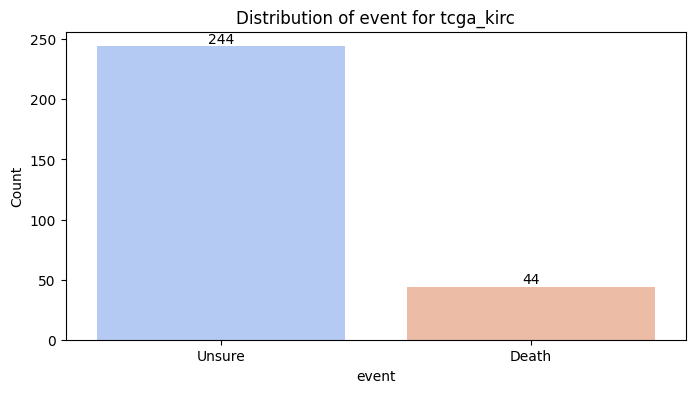

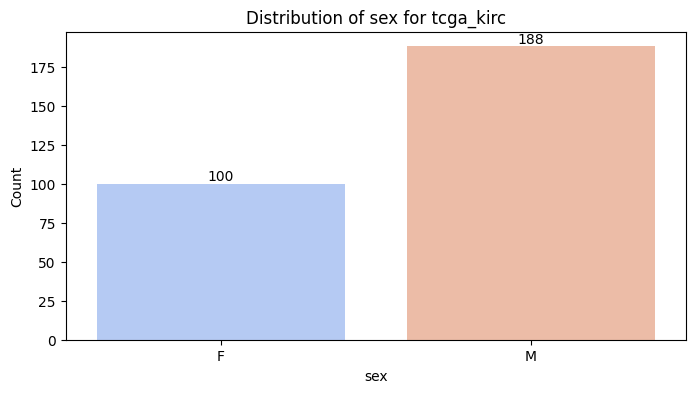

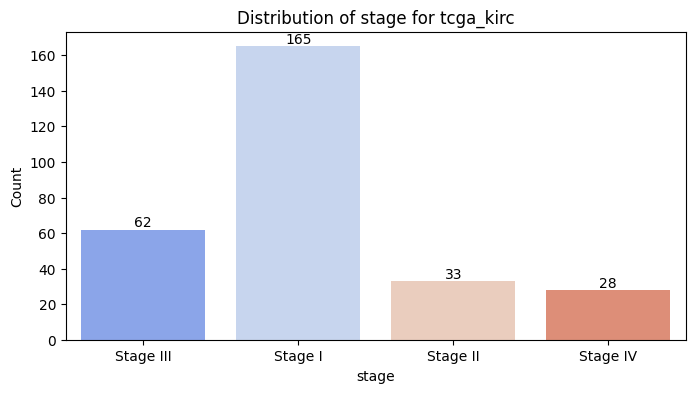

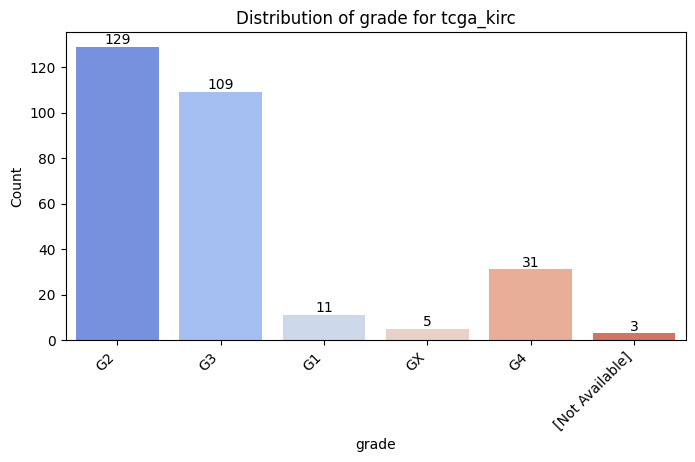

In [3]:
data_src = 'tcga_kirc' # OR 'tcga_brca', 'tcga_luad', 'tcga_kirc'
clinical_data_source = f'data_files/{data_src}/splits/0/train_filtered.csv'

data_df = pd.read_csv(clinical_data_source)
data_df_prepped = prepare_df_clinical_variables(data_df)

visualize_df(data_df_prepped, data_src)